In [11]:
import sys
!{sys.executable} -m pip install tensorflow

       producer_bhp_psi  gas_inj_rate_mscf_d  inj_bhp_limit_psi  \
count        200.000000           200.000000         200.000000   
mean        3092.320000            34.599700       10000.245000   
std          631.892585             3.672654         710.635362   
min         1504.000000            24.270000        8032.000000   
25%         3000.000000            34.610000       10000.000000   
50%         3000.000000            34.610000       10000.000000   
75%         3000.000000            34.610000       10000.000000   
max         4940.000000            44.750000       11934.000000   

       init_prod_period_days  perm_multiplier  poro_multiplier     final_fopt  \
count             200.000000       200.000000       200.000000     200.000000   
mean             3228.400000         1.012695         1.000025   75942.801850   
std               176.954811         0.277572         0.144975   10316.175931   
min              2730.000000         0.134000         0.504000   39410.7

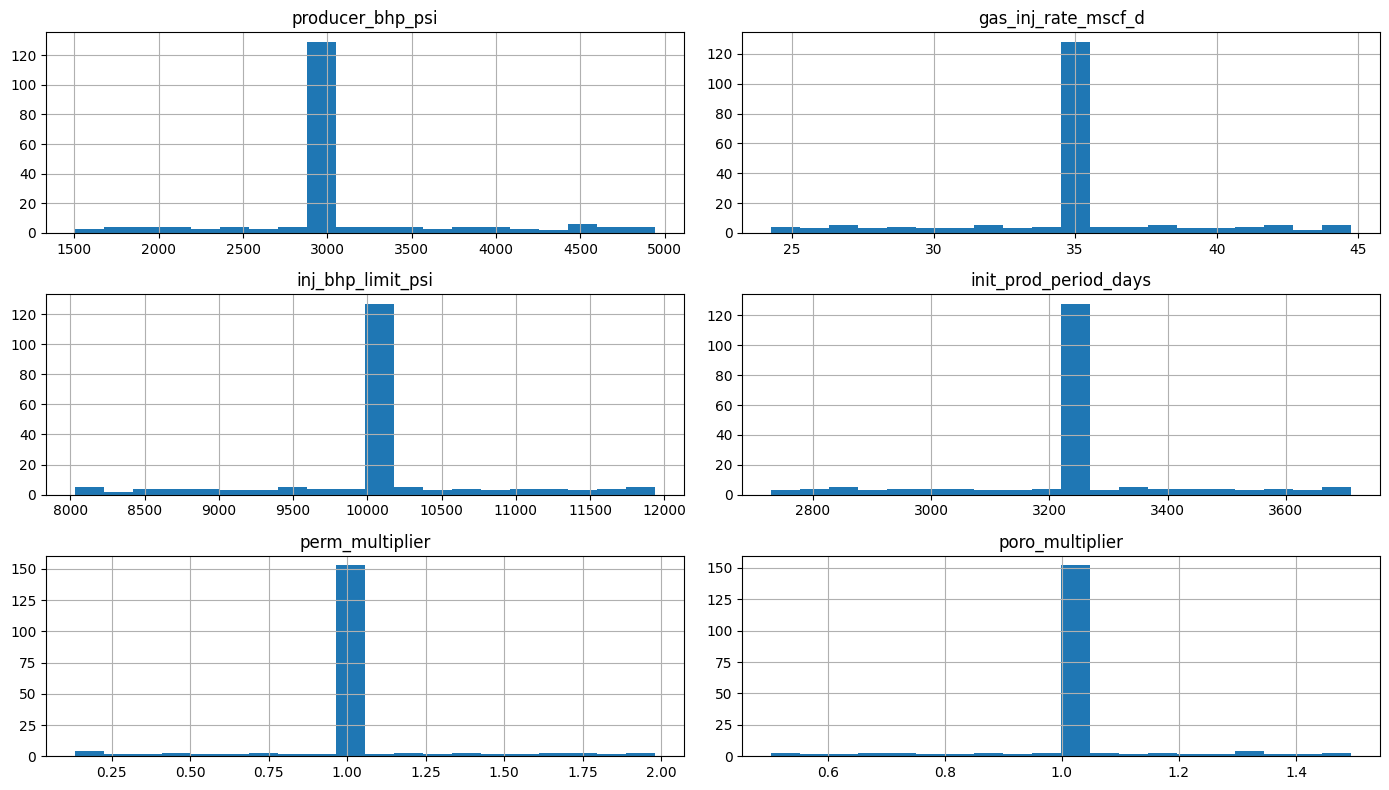

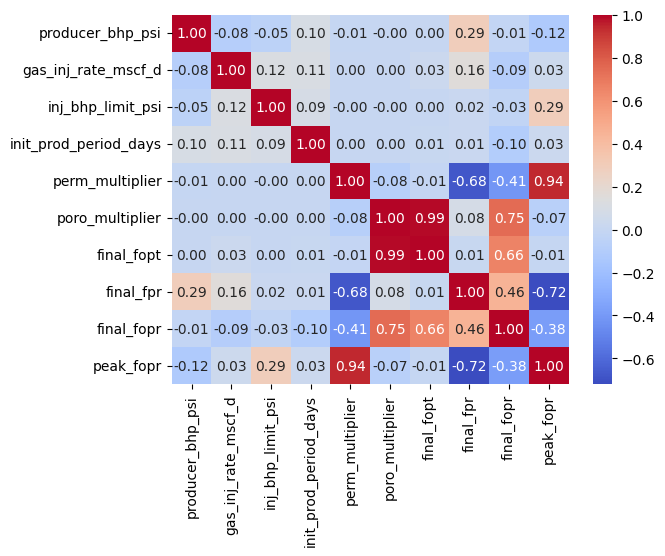

In [12]:
# Loading and exploring the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset_scalar.csv')

features = ['producer_bhp_psi','gas_inj_rate_mscf_d',
            'inj_bhp_limit_psi','init_prod_period_days',
            'perm_multiplier','poro_multiplier']
targets  = ['final_fopt','final_fpr','final_fopr','peak_fopr']

print(df[features + targets].describe())
print("Missing values:", df[features + targets].isnull().sum())

# Visualize feature distributions
df[features].hist(bins=20, figsize=(14, 8))
plt.tight_layout()
plt.show()

# Correlation heatmap
corr = df[features + targets].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [13]:
# Splitting into test, train, and validation sets

from sklearn.model_selection import train_test_split

X = df[features].values
y = df[targets].values

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
# → Train: 140 | Val: 30 | Test: 30

Train: 140 | Val: 30 | Test: 30


In [14]:
# Scaling the data, normalizing the features and targets

# Variables are on wildly different sets so need to get them aligned

from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit ONLY on training data, then transform all splits
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# To recover real units later:
# y_pred_real = scaler_y.inverse_transform(y_pred_scaled)

In [15]:
# Building the neural network architecture
# Input (6) -> Dense 128 + BN + ReLU + Drop -> Dense 64 + BN + ReLU + Drop -> Dense 32 + Drop -> Output (4)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_model(input_dim=6, output_dim=4, dropout_rate=0.1):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation='linear'),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate / 2),

        layers.Dense(output_dim)
    ])
    return model

model = build_model()
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile with Huber loss — more robust than MSE for physical outliers
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae']
)


In [17]:
# Training with early stopping

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,        # Wait 50 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,         # Halve the learning rate
    patience=20,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=500,         # Upper bound — early stopping will cut this short
    batch_size=16,      # Small batch suits small datasets
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 638ms/step - loss: 0.3385 - mae: 0.5846 - val_loss: 0.2452 - val_mae: 0.4602 - learning_rate: 0.0010
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2980 - mae: 0.5287 - val_loss: 0.2230 - val_mae: 0.4322 - learning_rate: 0.0010
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2796 - mae: 0.5023 - val_loss: 0.2068 - val_mae: 0.4127 - learning_rate: 0.0010
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2604 - mae: 0.4787 - val_loss: 0.1929 - val_mae: 0.3926 - learning_rate: 0.0010
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.2378 - mae: 0.4486 - val_loss: 0.1807 - val_mae: 0.3722 - learning_rate: 0.0010
Epoch 6/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.2173 - mae: 0.4176 - val_loss: 0.1680 - val_mae: 0.3555 - learning_rate: 0.0010
Epoch 7/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.2024 - mae: 0.4060 - val_loss: 0.1541 - val_mae: 0.3376 - learning_rate: 0.0010
Epoch 8/500
9/9 ━━━

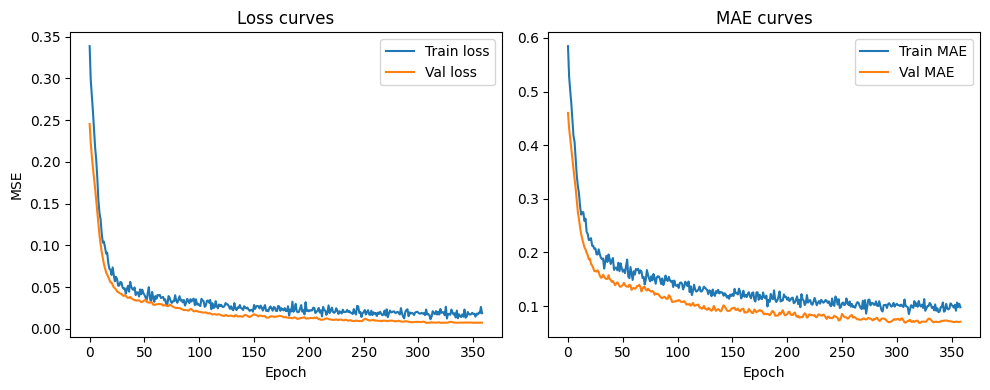

Test MSE (scaled): 0.0126
Test MAE (scaled): 0.0821
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
final_fopt           R²=0.996  MAE=539.2 STB
final_fpr            R²=0.972  MAE=56.3 psi
final_fopr           R²=0.964  MAE=0.0 STB/d
peak_fopr            R²=0.984  MAE=14.4 STB/d


In [18]:
# Evaluating and plotting the training curves

# Plot training curves
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.title('Loss curves')

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch'); plt.legend()
plt.title('MAE curves')
plt.tight_layout(); plt.show()

# Evaluate on held-out test set
test_loss, test_mae = model.evaluate(X_test_s, y_test_s, verbose=0)
print(f"Test MSE (scaled): {test_loss:.4f}")
print(f"Test MAE (scaled): {test_mae:.4f}")

# Convert predictions back to real units
y_pred_s = model.predict(X_test_s)
y_pred   = scaler_y.inverse_transform(y_pred_s)
y_true   = scaler_y.inverse_transform(y_test_s)

# Per-output R² score
from sklearn.metrics import r2_score
units = ['STB', 'psi', 'STB/d', 'STB/d']
for i, (name, unit) in enumerate(zip(targets, units)):
    r2  = r2_score(y_true[:,i], y_pred[:,i])
    mae = np.mean(np.abs(y_true[:,i] - y_pred[:,i]))
    print(f"{name:<20} R²={r2:.3f}  MAE={mae:,.1f} {unit}")

In [19]:
# Inference

# Example: predict for a new scenario
new_scenario = pd.DataFrame([{
    'producer_bhp_psi':    3000,
    'gas_inj_rate_mscf_d': 34.61,
    'inj_bhp_limit_psi':   10000,
    'init_prod_period_days': 3230,
    'perm_multiplier':     1.0,
    'poro_multiplier':     1.0
}])

X_new_s  = scaler_X.transform(new_scenario[features].values)
y_new_s  = model.predict(X_new_s)
y_new    = scaler_y.inverse_transform(y_new_s)

print(f"Predicted final_fopt  : {y_new[0,0]:,.0f} STB")
print(f"Predicted final_fpr   : {y_new[0,1]:,.1f} psi")
print(f"Predicted final_fopr  : {y_new[0,2]:,.3f} STB/d")
print(f"Predicted peak_fopr   : {y_new[0,3]:,.1f} STB/d")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Predicted final_fopt  : 76,149 STB
Predicted final_fpr   : 3,993.1 psi
Predicted final_fopr  : 0.432 STB/d
Predicted peak_fopr   : 604.1 STB/d


In [ ]:
import joblib, os
os.makedirs('saved_models', exist_ok=True)
model.save('saved_models/mlp_reservoir_proxy.keras')
joblib.dump(scaler_X, 'saved_models/mlp_scaler_X.pkl')
joblib.dump(scaler_y, 'saved_models/mlp_scaler_y.pkl')
import json as _json
_meta = {'features': features, 'targets': targets}
with open('saved_models/mlp_metadata.json', 'w') as _f:
    _json.dump(_meta, _f, indent=2)
print("MLP model and scalers saved to saved_models/")